In [1]:
import os
# os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

import sys

sys.path.insert(0, "../..")

In [2]:
import chex
import jax
import jax.numpy as jnp
import jax.random as jrandom
import math
import matplotlib.pyplot as plt
import numpy as np
import optax

from flax import nnx
from functools import partial
from jax_tqdm import loop_tqdm
from tqdm.notebook import tqdm
from typing import Any, NamedTuple

from src.decoding import make_autoregressive
from src.models.gpt import InContextGPTWithThoughts
from src.models.next_token import TokenEmbedders
from src.models.nope import NoPE
from src.models import TrainState

## Hyperparameters

In [ ]:
num_blocks = 2
num_heads = 2
embed_dim = 32
widening_factor = 4
dtype = jnp.float32

num_input_tokens = 5 # 0, 1, latent start, latent end, EOS
num_output_tokens = 2
start_thinking_token = 2
end_thinking_token = 3
eos_token = 4

train_type = "rl" # ["sft", "rl"]

lr = 1e-3
max_grad_norm = 1.0
# max_grad_norm = False
max_iter = 10000
log_interval = 100
print_rate = 1000

seed = 42
rngs = nnx.Rngs(seed)

max_input_len = 5
max_thought_len = max_input_len
max_output_len = 4
num_questions = 2
rollout_samples = 8


think_phase_len = max_thought_len + max_input_len
output_phase_len = max_thought_len + max_input_len + max_output_len
batch_size = int(rollout_samples * num_questions)

In [4]:
model = InContextGPTWithThoughts(
    num_blocks,
    num_heads,
    embed_dim,
    widening_factor,
    partial(
        TokenEmbedders,
        num_input_tokens=num_input_tokens,
        num_output_tokens=num_output_tokens,
        embed_dim=embed_dim,
        rngs=rngs,
        shared_decoding=True,
        decode=False,
        dtype=dtype,
    ),
    partial(NoPE),
    rngs,
)

graphdef, params, rest = nnx.split(model, nnx.Param, ...)

opt_transforms = []
if max_grad_norm:
    opt_transforms.append(
        optax.clip_by_global_norm(max_grad_norm)
    )
opt_transforms.append(optax.adam(lr))
opt = optax.chain(*opt_transforms)

train_state = TrainState.create(
    apply_fn=graphdef.apply,
    params=params,
    tx=opt,
    graphdef=graphdef,
    rest=rest,
)

TODO:
- The latent thought can be done without parallelizing first---parallelization at output phase
- Right now this is trained end-to-end, perhaps we can do an alternate training

## Rollout and utils helpers

In [5]:
class ReadStepState(NamedTuple):
    graphdef: Any
    rest: Any
    cache: Any
    last_prompt_idx: int
    question_embedding: chex.Array
    last_output: chex.Array

class ThinkStepState(NamedTuple):
    graphdef: Any
    rest: Any
    cache: Any
    thought_length: int
    thought: chex.Array

class ActStepState(NamedTuple):
    graphdef: Any
    rest: Any
    cache: Any
    eos_token: int
    rng: jrandom.PRNGKey
    act_embeds: chex.Array
    logits: chex.Array
    actions: chex.Array
    eos: chex.Array
    deterministic: int = 0


def get_default(embed_seq):
    return jnp.zeros_like(embed_seq)

def select_new_cache(new_cache, cache):
    return new_cache

def select_old_cache(new_cache, cache):
    return cache

def _read_token(
    step_i,
    graphdef,
    cache,
    rest,
    last_prompt_idx,
    question_embedding,
    last_output,
):
    module = nnx.merge(graphdef, cache, rest)
    module.eval()
    module.set_attributes(deterministic=True, decode=True)

    is_prompt = step_i <= last_prompt_idx # The start think token is read at last_prompt_idx
    next_output = module.get_next_embedding_prediction(
        question_embedding[:, [step_i]],
    )[:, 0]
    new_cache = nnx.state(module, nnx.Cache)

    last_output = jax.lax.select(
        is_prompt,
        next_output,
        last_output,
    )

    cache = nnx.cond(
        is_prompt,
        select_new_cache,
        select_old_cache,
        new_cache,
        cache,
    )

    return cache, last_output

def _think_token(
    step_i,
    graphdef,
    cache,
    rest,
    thought_length,
    thought,
):
    module = nnx.merge(graphdef, cache, rest)
    module.eval()
    module.set_attributes(deterministic=True, decode=True)

    is_thought = step_i < thought_length - 1 # The start think is the last read token
    next_output = module.get_next_embedding_prediction(
        thought[:, [step_i]],
    )[:, 0]
    new_cache = nnx.state(module, nnx.Cache)

    last_output = jax.lax.select(
        is_thought,
        next_output,
        thought[:, step_i + 1],
    )

    cache = nnx.cond(
        is_thought,
        select_new_cache,
        select_old_cache,
        new_cache,
        cache,
    )

    return cache, last_output

def _act_token(
    step_i,
    graphdef,
    cache,
    rest,
    eos_token,
    rng,
    actions,
    eos,
    deterministic,
):
    rng, rng_step = jrandom.split(rng)
    module = nnx.merge(graphdef, cache, rest)
    module.eval()
    module.set_attributes(deterministic=True, decode=True)

    action_embedding = module.get_embedding(actions[:, [step_i]])
    act_embed = module.get_next_embedding_prediction(
        action_embedding
    )[:, 0]
    cache = nnx.state(module, nnx.Cache)
    
    logit = module.get_unembedding(act_embed)
    
    action = jax.lax.cond(
        deterministic,
        lambda rng_step, logit: jnp.argmax(logit, axis=-1),
        jrandom.categorical,
        rng_step,
        logit,
    )

    is_eos = jnp.logical_or(
        action == eos_token,
        eos[:, step_i],
    )

    return cache, act_embed, logit, action, is_eos, rng

read_token = jax.vmap(_read_token, in_axes=[None, None, 0, 0, 0, 0, 0])
think_token = jax.vmap(_think_token, in_axes=[None, None, 0, 0, 0, 0])
act_token = jax.vmap(_act_token, in_axes=[None, None, 0, 0, 0, 0, 0, 0, 0])

def read_step(
    step_i: int,
    step_state: ReadStepState,
):
    cache, last_output = read_token(
        step_i,
        step_state.graphdef,
        step_state.cache,
        step_state.rest,
        step_state.last_prompt_idx,
        step_state.question_embedding,
        step_state.last_output,
    )
    
    return ReadStepState(
        graphdef=step_state.graphdef,
        rest=step_state.rest,
        cache=cache,
        question_embedding=step_state.question_embedding,
        last_prompt_idx=step_state.last_prompt_idx,
        last_output=last_output,
    )

def think_step(
    step_i: int,
    step_state: ThinkStepState,
):
    cache, last_output = think_token(
        step_i,
        step_state.graphdef,
        step_state.cache,
        step_state.rest,
        step_state.thought_length,
        step_state.thought,
    )
    
    return ThinkStepState(
        graphdef=step_state.graphdef,
        rest=step_state.rest,
        cache=cache,
        thought_length=step_state.thought_length,
        thought=step_state.thought.at[:, :, step_i + 1].set(last_output),
    )

def act_step(
    step_i: int,
    step_state: ActStepState,
):
    cache, act_embed, logit, action, is_eos, rng = act_token(
        step_i,
        step_state.graphdef,
        step_state.cache,
        step_state.rest,
        step_state.eos_token,
        step_state.rng,
        step_state.actions,
        step_state.eos,
        step_state.deterministic,
    )
    
    return ActStepState(
        graphdef=step_state.graphdef,
        rest=step_state.rest,
        cache=cache,
        eos_token=step_state.eos_token,
        rng=rng,
        act_embeds=step_state.act_embeds.at[:, :, step_i + 1].set(act_embed),
        logits=step_state.logits.at[:, :, step_i + 1].set(logit),
        actions=step_state.actions.at[:, :, step_i + 1].set(action),
        eos=step_state.eos.at[:, :, step_i + 1].set(is_eos),
        deterministic=step_state.deterministic,
    )

In [6]:
def complexity_fn(last_prompt_idx):
    return last_prompt_idx + 1

In [7]:
def match_action(action, answer, answer_len):
    match_mask = jnp.zeros(len(action))
    match_mask = match_mask.at[answer_len].set(1)
    match_mask = jnp.cumsum(match_mask)
    return {
        "success": jnp.all((action == answer) * (1 - match_mask) + match_mask).astype(int),
        "mask": 1 - match_mask,
    }


In [8]:
def l2_norm(params):
    return sum(jnp.sum(p**2) for p in jax.tree_util.tree_leaves(params))

## Dataset

In [ ]:
questions = jnp.array([
    [0, 1, start_thinking_token, eos_token, eos_token],
    [1, start_thinking_token, eos_token, eos_token, eos_token],
])
answer = jnp.array([
    [0, 1, eos_token, eos_token],
    [1, eos_token, eos_token, eos_token],
])
last_prompt_idx = jnp.array([
    2,
    1,
])
thought_length = complexity_fn(last_prompt_idx)
last_thought_idx = last_prompt_idx + thought_length
answer_len = jnp.array([
    2,
    1,
])

questions = jnp.repeat(
    questions,
    rollout_samples,
    axis=0,
)
answer = jnp.repeat(
    answer,
    rollout_samples,
    axis=0,
)
last_prompt_idx = jnp.repeat(
    last_prompt_idx,
    rollout_samples,
    axis=0,
)
last_thought_idx = jnp.repeat(
    last_thought_idx,
    rollout_samples,
    axis=0,
)
thought_length = jnp.repeat(
    thought_length,
    rollout_samples,
    axis=0,
)
answer_len = jnp.repeat(
    answer_len,
    rollout_samples,
    axis=0,
)

questions = jax.device_put(questions)
answer = jax.device_put(answer)
last_prompt_idx = jax.device_put(last_prompt_idx)
last_thought_idx = jax.device_put(last_thought_idx)
thought_length = jax.device_put(thought_length)
answer_len = jax.device_put(answer_len)

rollout_rng = jrandom.split(jrandom.PRNGKey(seed), batch_size)

## E2E-RL

In [10]:
@jax.jit
@partial(jax.value_and_grad, has_aux=True)
def compute_rl_loss(params, rng):
    module = nnx.merge(train_state.graphdef, params, train_state.rest)
    _, init_cache = make_autoregressive(
        module,
        max_decode_len=output_phase_len,
        batch_size=1,
        embed_dim=embed_dim,
        dtype=dtype,
        eval_mode=True,
    )
    cache = init_cache()
    graphdef, _, rest = nnx.split(module, nnx.Cache, ...)

    questions_embedding = module.get_embedding(questions)

    def initialize_read_step_state(question_embedding, last_prompt_idx):
        return ReadStepState(
            graphdef=graphdef,
            rest=rest,
            cache=cache,
            question_embedding=question_embedding,
            last_prompt_idx=last_prompt_idx,
            last_output=jnp.zeros((1, embed_dim)),
        )

    def initialize_think_step_state(thought_length, last_read_output, read_cache):
        thought = jnp.zeros((1, max_thought_len, embed_dim))
        thought = thought.at[:, 0].set(last_read_output)
        return ThinkStepState(
            graphdef=graphdef,
            rest=rest,
            cache=read_cache,
            thought_length=thought_length,
            thought=thought,
        )

    def initialize_act_step_state(think_cache, rng):
        actions = jnp.zeros((1, max_output_len + 1), dtype=int)
        actions = actions.at[:, 0].set(end_thinking_token)
        return ActStepState(
            graphdef=graphdef,
            rest=rest,
            cache=think_cache,
            eos_token=eos_token,
            rng=rng,
            act_embeds=jnp.zeros((1, max_output_len + 1, embed_dim)),
            logits=jnp.zeros((1, max_output_len + 1, num_output_tokens)),
            actions=actions,
            eos=jnp.zeros((1, max_output_len + 1)),
            deterministic=0,
        )

    read_step_state = nnx.vmap(initialize_read_step_state)(
        questions_embedding[:, None],
        last_prompt_idx,
    )

    read_step_state = jax.lax.fori_loop(
        0,
        max_input_len,
        read_step,
        read_step_state,
    )

    think_step_state = nnx.vmap(initialize_think_step_state)(
        thought_length,
        read_step_state.last_output,
        read_step_state.cache,
    )

    think_step_state = jax.lax.fori_loop(
        0,
        max_thought_len,
        think_step,
        think_step_state,
    )


    act_step_state = nnx.vmap(initialize_act_step_state)(
        think_step_state.cache,
        rollout_rng
    )

    act_step_state = jax.lax.fori_loop(
        0,
        max_output_len,
        act_step,
        act_step_state,
    )

    actions = act_step_state.actions[:, 0, 1:]

    res = jax.vmap(match_action)(actions, answer, answer_len)
    match_mask = res["mask"]
    success = res["success"]
    rewards = (-1) ** (1 - success)
    # rewards = success

    logits = act_step_state.logits[:, 0, 1:]

    one_hot_actions = jax.nn.one_hot(actions, num_classes=logits.shape[-1])

    lprobs = jnp.sum(
        logits, axis=-1, where=one_hot_actions,
    ) - jax.nn.logsumexp(logits, axis=-1)

    return -jnp.mean(jnp.sum(lprobs, axis=-1, where=match_mask) * rewards), {
        "actions": actions,
        "success": success,
        "logits": logits,
        "match_mask": match_mask,
        "read_step_state": read_step_state,
        "think_step_state": think_step_state,
        "act_step_state": act_step_state,
    }

## General training loop

In [11]:
if train_type == "rl":
    compute_loss = compute_rl_loss
else:
    raise NotImplementedError

In [12]:
class LogStepState(NamedTuple):
    train_state: TrainState
    losses: chex.Array
    successes: chex.Array
    entropies: chex.Array
    grad_norms: chex.Array
    param_norms: chex.Array

@jax.jit
@loop_tqdm(max_iter, print_rate=print_rate)
def train_step(
    step_i: int,
    step_state: LogStepState,
):
    train_state = step_state.train_state
    (loss, aux), grads = compute_loss(
        train_state.params,
        jax.vmap(
            jrandom.fold_in,
            in_axes=[0, None],
        )(
            rollout_rng,
            step_i,
        )
    )
    train_state = train_state.apply_gradients(grads=grads)

    success_rate = jnp.mean(aux["success"])

    match_mask = aux["match_mask"]
    logits = aux["logits"].reshape((batch_size, max_output_len, -1))
    probs = jax.nn.softmax(logits, axis=-1)
    entropies = optax.softmax_cross_entropy(logits, probs)
    entropies = jnp.mean(entropies, where=match_mask)

    is_log = step_i % log_interval == 0
    log_idx = step_i // log_interval
    losses = jax.lax.select(
        is_log,
        step_state.losses.at[log_idx].set(loss),
        step_state.losses,
    )
    successes = jax.lax.select(
        is_log,
        step_state.successes.at[log_idx].set(success_rate),
        step_state.successes,
    )
    
    entropies = jax.lax.select(
        is_log,
        step_state.entropies.at[log_idx].set(entropies),
        step_state.entropies,
    )

    grad_norms = jax.lax.select(
        is_log,
        step_state.grad_norms.at[log_idx].set(l2_norm(grads)),
        step_state.grad_norms,
    )

    param_norms = jax.lax.select(
        is_log,
        step_state.param_norms.at[log_idx].set(l2_norm(train_state.params)),
        step_state.param_norms,
    )

    return LogStepState(
        train_state,
        losses,
        successes,
        entropies,
        grad_norms,
        param_norms,
    )

## Experiments

In [13]:
logs = jax.lax.fori_loop(
    0,
    max_iter,
    train_step,
    LogStepState(
        train_state,
        jnp.zeros(math.ceil(max_iter / log_interval)),
        jnp.zeros(math.ceil(max_iter / log_interval)),
        jnp.zeros(math.ceil(max_iter / log_interval)),
        jnp.zeros(math.ceil(max_iter / log_interval)),
        jnp.zeros(math.ceil(max_iter / log_interval)),
    )
)

Running for 10,000 iterations:   0%|          | 0/10000 [00:00<?, ?it/s]

In [14]:
def smooth_lists(iterations, lists, N):
    if N == 1:
        return iterations[:], lists[:]

    smoothed_lists = []
    for curr_list in lists:
        curr_list = np.array(curr_list)
        smoothed = np.convolve(curr_list, np.ones(N)/N, mode='valid')
        smoothed_lists.append(smoothed)
    iterations = np.array(iterations)
    smoothed_iter = iterations[N-1:]
    
    return smoothed_iter, smoothed_lists

In [15]:
smooth_window = 1
smoothed_iter, smoothed_res = smooth_lists(
    np.arange(len(logs.losses)) * log_interval,
    [
        logs.losses,
        logs.successes,
        logs.entropies,
        logs.grad_norms,
        logs.param_norms,
    ],
    smooth_window,
)

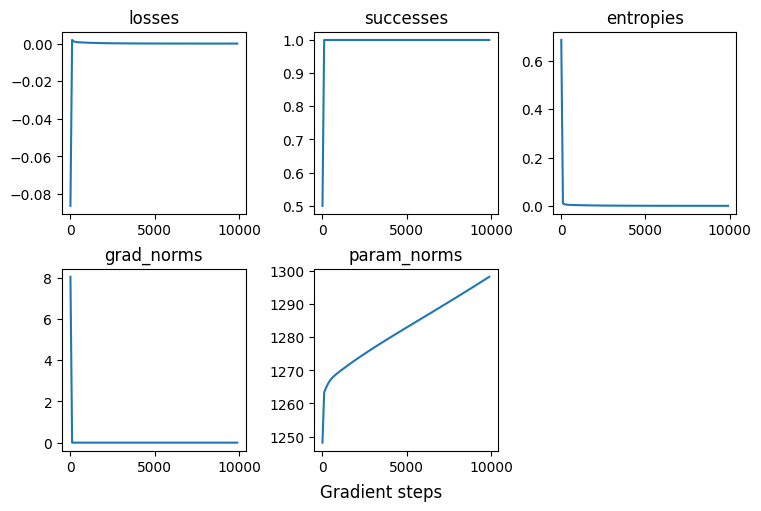

In [16]:
num_cols = 3
num_rows = math.ceil(len(smoothed_res) / num_cols)

fig, axes = plt.subplots(
    num_rows,
    num_cols,
    layout="constrained",
    figsize=(2.5 * num_cols, 2.5 * num_rows),
)

keys = [
    "losses",
    "successes",
    "entropies",
    "grad_norms",
    "param_norms",
]

axes = axes.flatten()
for ax_i, (key, value) in enumerate(zip(keys, smoothed_res)):
    ax = axes[ax_i]
    ax.plot(smoothed_iter, value)
    ax.set_title(key)

fig.supxlabel("Gradient steps")

for i in range(len(keys), len(axes)):
    fig.delaxes(axes[i])

In [17]:
assert 0
import dill

dill.dump(
    logs.train_state,
    open("latent_thoughts_run.dill", "wb")
)

AssertionError: 

## Debug

In [18]:
module = nnx.merge(logs.train_state.graphdef, logs.train_state.params, logs.train_state.rest)
_, init_cache = make_autoregressive(
    module,
    max_decode_len=output_phase_len,
    batch_size=1,
    embed_dim=embed_dim,
    dtype=dtype,
    eval_mode=True,
)
cache = init_cache()
graphdef, _, rest = nnx.split(module, nnx.Cache, ...)

questions_embedding = module.get_embedding(questions)

def initialize_read_step_state(question_embedding, last_prompt_idx):
    return ReadStepState(
        graphdef=graphdef,
        rest=rest,
        cache=cache,
        question_embedding=question_embedding,
        last_prompt_idx=last_prompt_idx,
        last_output=jnp.zeros((1, embed_dim)),
    )

def initialize_think_step_state(thought_length, last_read_output, read_cache):
    thought = jnp.zeros((1, max_thought_len, embed_dim))
    thought = thought.at[:, 0].set(last_read_output)
    return ThinkStepState(
        graphdef=graphdef,
        rest=rest,
        cache=read_cache,
        thought_length=thought_length,
        thought=thought,
    )

def initialize_act_step_state(think_cache, rng):
    actions = jnp.zeros((1, max_output_len + 1), dtype=int)
    actions = actions.at[:, 0].set(end_thinking_token)
    return ActStepState(
        graphdef=graphdef,
        rest=rest,
        cache=think_cache,
        eos_token=eos_token,
        rng=rng,
        act_embeds=jnp.zeros((1, max_output_len + 1, embed_dim)),
        logits=jnp.zeros((1, max_output_len + 1, num_output_tokens)),
        actions=actions,
        eos=jnp.zeros((1, max_output_len + 1)),
        deterministic=0,
    )

read_step_state = nnx.vmap(initialize_read_step_state)(
    questions_embedding[:, None],
    last_prompt_idx,
)

read_step_state = jax.lax.fori_loop(
    0,
    max_input_len,
    read_step,
    read_step_state,
)

think_step_state = nnx.vmap(initialize_think_step_state)(
    thought_length,
    read_step_state.last_output,
    read_step_state.cache,
)

think_step_state = jax.lax.fori_loop(
    0,
    max_thought_len,
    think_step,
    think_step_state,
)


act_step_state = nnx.vmap(initialize_act_step_state)(
    think_step_state.cache,
    rollout_rng
)

act_step_state = jax.lax.fori_loop(
    0,
    max_output_len,
    act_step,
    act_step_state,
)

In [19]:
actions = act_step_state.actions[:, 0, 1:]

res = jax.vmap(match_action)(actions, answer, answer_len)
match_mask = res["mask"]
success = res["success"]
# rewards = (-1) ** (1 - success)
rewards = success

In [20]:
rewards

Array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [21]:
questions

Array([[0, 1, 2, 4, 4],
       [0, 1, 2, 4, 4],
       [0, 1, 2, 4, 4],
       [0, 1, 2, 4, 4],
       [0, 1, 2, 4, 4],
       [0, 1, 2, 4, 4],
       [0, 1, 2, 4, 4],
       [0, 1, 2, 4, 4],
       [1, 2, 4, 4, 4],
       [1, 2, 4, 4, 4],
       [1, 2, 4, 4, 4],
       [1, 2, 4, 4, 4],
       [1, 2, 4, 4, 4],
       [1, 2, 4, 4, 4],
       [1, 2, 4, 4, 4],
       [1, 2, 4, 4, 4]], dtype=int32)

In [22]:
actions

Array([[0, 1, 1, 1],
       [0, 1, 1, 1],
       [0, 1, 1, 1],
       [0, 1, 1, 1],
       [0, 1, 1, 1],
       [0, 1, 1, 1],
       [0, 1, 1, 1],
       [0, 1, 1, 1],
       [1, 0, 1, 1],
       [1, 0, 1, 1],
       [1, 0, 1, 1],
       [1, 0, 1, 1],
       [1, 0, 1, 1],
       [1, 0, 1, 1],
       [1, 0, 1, 1],
       [1, 0, 1, 1]], dtype=int32)